In [14]:
import numpy as np

geno = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")
recon = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae/recon_all.npy")

# If geno is in {0,1,2}, scale to [0,1] to match recon:
geno_scaled = geno / 2.0

mse = np.mean((geno_scaled - recon)**2)
mae = np.mean(np.abs(geno_scaled - recon))

print("Per-entry MSE:", mse)
print("Per-entry MAE:", mae)


Per-entry MSE: 0.04994251
Per-entry MAE: 0.0845734


In [15]:
snp_means = geno_scaled.mean(axis=0, keepdims=True)
mse_baseline = np.mean((geno_scaled - snp_means)**2)
print("Baseline MSE:", mse_baseline)


Baseline MSE: 0.017931603


In [16]:
geno.shape

(1000, 10000)

In [12]:
# load the .trees sequence
import tskit
import numpy as np
ts = tskit.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae_sims/0/rep0/tree_sequence.trees")

In [13]:
G = ts.genotype_matrix()
G.shape

(677315, 2000)

In [14]:
biallelic = np.max(G, axis=1) <= 1

In [15]:
print(f'Number of non-biallelic variants: {G.shape[0] - biallelic.sum()}')

Number of non-biallelic variants: 1543


In [16]:
genotype_matrix = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")

In [17]:
genotype_matrix.shape

(1000, 10000)

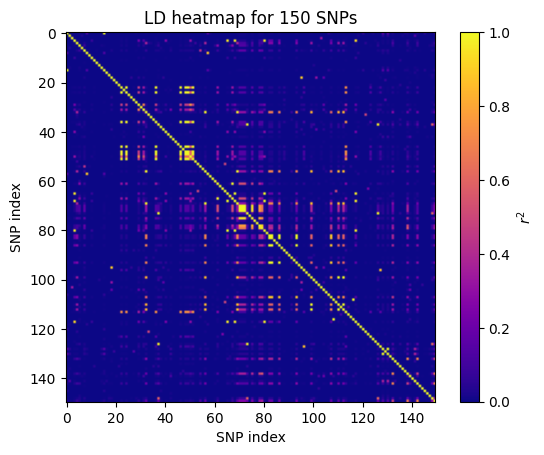

In [24]:
# Plot LD
import numpy as np

G = genotype_matrix.astype(np.float32)  # (1000, 10000), entries 0/1/2
n_snps = 150
start = (G.shape[1] - n_snps)//2
X = G[:, start:start+n_snps]

# mean-center and standardize each SNP
X = X - X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)
keep = (std[0] > 0)   # drop monomorphic
X = X[:, keep]
X = X / std[:, keep]

# correlation and r^2
R = (X.T @ X) / X.shape[0]
r2 = R * R
np.fill_diagonal(r2, 1.0)

r2.shape
import matplotlib.pyplot as plt
plt.imshow(r2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='$r^2$')
plt.title(F'LD heatmap for {n_snps} SNPs')
plt.xlabel('SNP index')
plt.ylabel('SNP index')
plt.show()
